In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('affiliation-researchers-building-artificial-intelligence-systems-all.csv')

print(df.shape) #rows and columns as numbers
print(df.columns.tolist()) #column names
print(df.head(10)) #first 10 rows

df_wide=df.pivot(index='Year', columns='Entity', values='Annual number of AI systems by researcher affiliation') #pivot the data to wide format
print(df_wide.head(10)) #first 10 rows of the wide format data

print(df_wide.isna().sum()) #check for missing values

full_years = range(df_wide.index.min(),df_wide.index.max()+1) #create a list of all years in the data
df_wide = df_wide.reindex(full_years,fill_value=0) #fill missing years with 0
print(df_wide.shape) 

(244, 3)
['Entity', 'Year', 'Annual number of AI systems by researcher affiliation']
     Entity  Year  Annual number of AI systems by researcher affiliation
0  Academia  1950                                                  0    
1  Academia  1952                                                  1    
2  Academia  1954                                                  1    
3  Academia  1955                                                  2    
4  Academia  1957                                                  1    
5  Academia  1959                                                  1    
6  Academia  1960                                                  2    
7  Academia  1962                                                  1    
8  Academia  1963                                                  0    
9  Academia  1965                                                  1    
Entity  Academia  Academia and industry collaboration  Industry  Other
Year                                     

# Master visualization correction

Colors were not changed because the master visualization was the reproduction of the OWID data visualization. Below are the things improved. 

## Not met category
- added a title
- removed the border lines

## Partially met 
- removed unnecessary tick marks
- added an annotation showing the main finding (Industry = 97 of 106 systems in 2025)

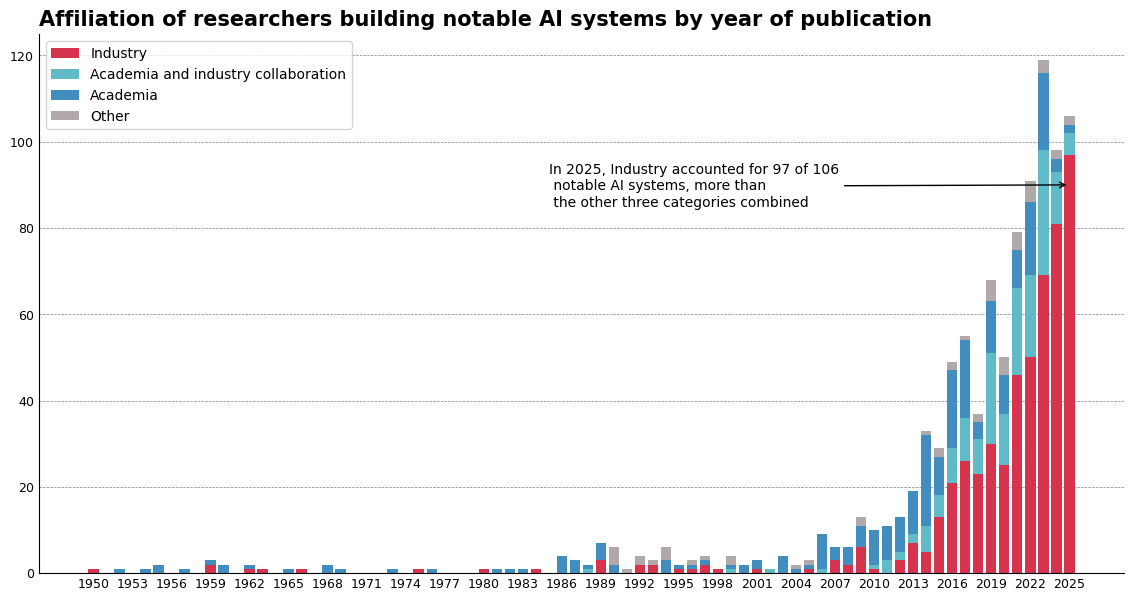

In [2]:
categories = ['Industry', 'Academia and industry collaboration', 'Academia', 'Other'] #order of categories to plot
years = df_wide.index 

bottom = pd.Series(0,index=years) #chart bottom 0

fig,ax = plt.subplots(figsize = (14,7)) 

color_map = {
    'Academia': '#418dc0',
    'Academia and industry collaboration': '#60bbc8',
    'Industry': '#d5344c',
    'Other': '#b1a8a9'
}

for category in categories:
    ax.bar(years,df_wide[category],bottom=bottom,label=category,color =color_map[category]) #plot the bar chart for each category
    bottom+=df_wide[category] #update bottom for next category

ax.legend()

start_year = df_wide.index.min()
end_year = df_wide.index.max()
ax.set_xticks(range(start_year, end_year + 1, 3)); #set x ticks for every 3 years

ax.set_axisbelow(True) #set grid lines below the bars
ax.grid(axis='y', color='gray', linestyle='dashed', linewidth=0.5) #grid line 

#master visualization corrections
ax.set_title('Affiliation of researchers building notable AI systems by year of publication', fontsize=15, loc='left', fontweight='bold') #title
ax.annotate(
    "In 2025, Industry accounted for 97 of 106\n notable AI systems, more than\n the other three categories combined",
    xy=(2025, 90), xytext=(1985, 85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False) # no border line
ax.tick_params(axis='both', length=0, labelsize=9)

plt.show()


# Color reproduction

This chart uses my own colour choices. 

- added hatch patterns to Academia and Academia+industry
- changed Other to a lighter colour so it doesn't blend with Industry or for colorblind viewers
- same title, annotation, and border/tick fixes as the first 

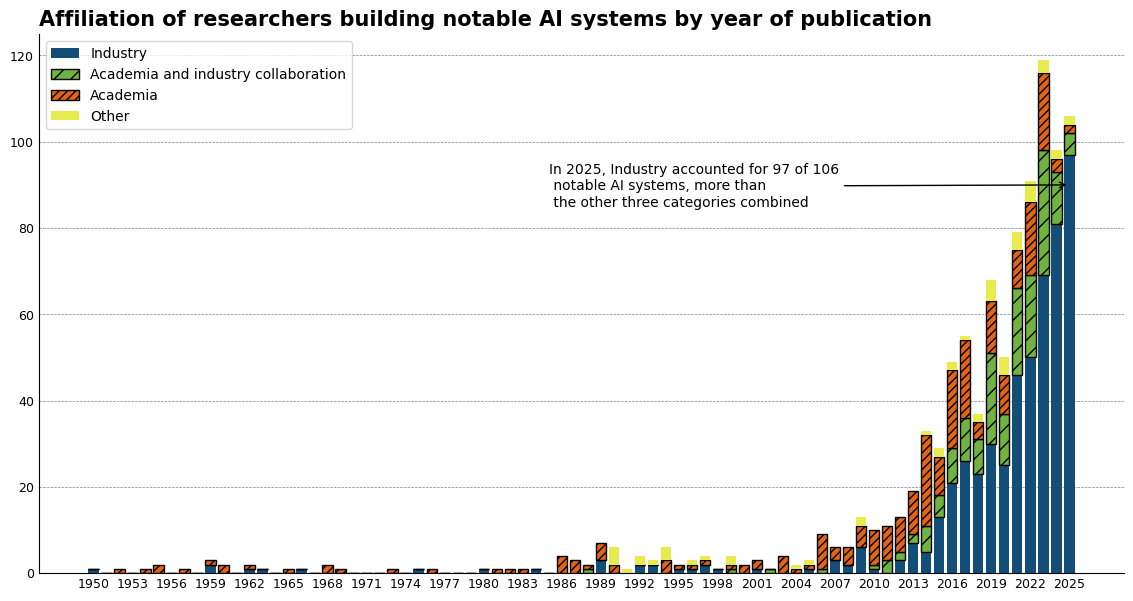

In [3]:
categories = ['Industry', 'Academia and industry collaboration', 'Academia', 'Other'] #order of categories to plot
years = df_wide.index 

bottom = pd.Series(0,index=years) #chart bottom 0

fig,ax = plt.subplots(figsize = (14,7)) 

color_map = {
    'Industry': '#124E78',
    'Academia and industry collaboration': '#71B340',
    'Academia': '#E36414',
    'Other': "#E8EB4E"
}


hatch_map = {
    'Industry': '',
    'Academia and industry collaboration': '//',
    'Academia': '////',
    'Other': ''
} #hatch patterns for each category


for category in categories:
    bars = ax.bar(years, df_wide[category], bottom=bottom, label=category,
                   color=color_map[category], hatch=hatch_map[category])
    if hatch_map[category]:
        for b in bars:
            b.set_edgecolor('black')  #hatch pattern edge color
    bottom += df_wide[category]
    
ax.legend()

start_year = df_wide.index.min()
end_year = df_wide.index.max()
ax.set_xticks(range(start_year, end_year + 1, 3)); #set x ticks for every 3 years

ax.set_axisbelow(True) #set grid lines below the bars
ax.grid(axis='y', color='gray', linestyle='dashed', linewidth=0.5) #grid line 

#master visualization corrections
ax.set_title('Affiliation of researchers building notable AI systems by year of publication', fontsize=15, loc='left', fontweight='bold') #title
ax.annotate(
    "In 2025, Industry accounted for 97 of 106\n notable AI systems, more than\n the other three categories combined",
    xy=(2025, 90), xytext=(1985, 85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False) # no border line
ax.tick_params(axis='both', length=0, labelsize=9)

plt.show()
